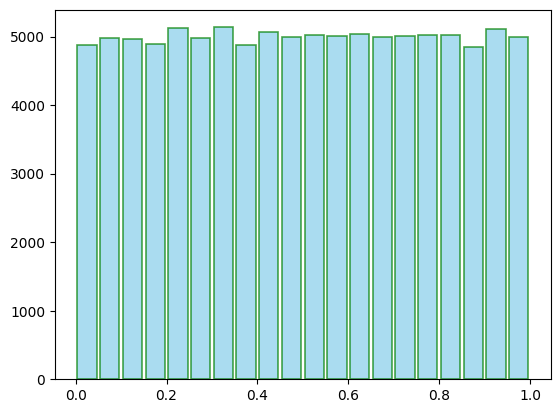

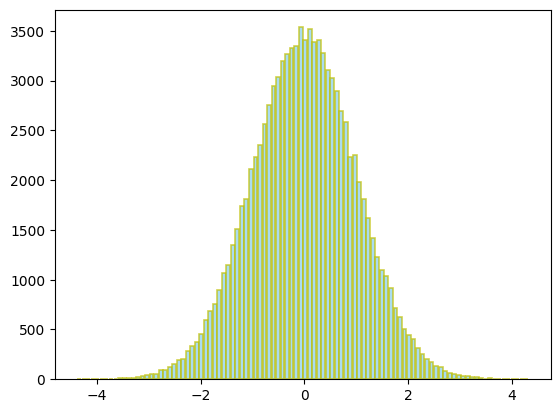

0.0488


In [27]:
#for two populations from stantard normal distribution, do t-test for M =10000 times.
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

M = 100000
n1, n2 = 100, 100
mu1, mu2 = 0, 0
sigma1, sigma2 = 1, 1
s1, s2 =np.sqrt(sigma1), np.sqrt(sigma2)
alpha = 0.05
reject = 0
x1 = np.random.normal(mu1, s1, (n1,M))
x2 = np.random.normal(mu2, s2, (n2,M))
results = ttest_ind(x1, x2, equal_var=False)
plt.hist(results.pvalue, bins=20, color='skyblue', alpha=0.7, rwidth=0.85, edgecolor='green', linewidth=1.2)
plt.show()
plt.hist(results.statistic, bins=100, color='skyblue', alpha=0.7, rwidth=0.85, edgecolor='y', linewidth=1.2)
plt.show()
power = np.mean(results.pvalue < alpha)
print(power)





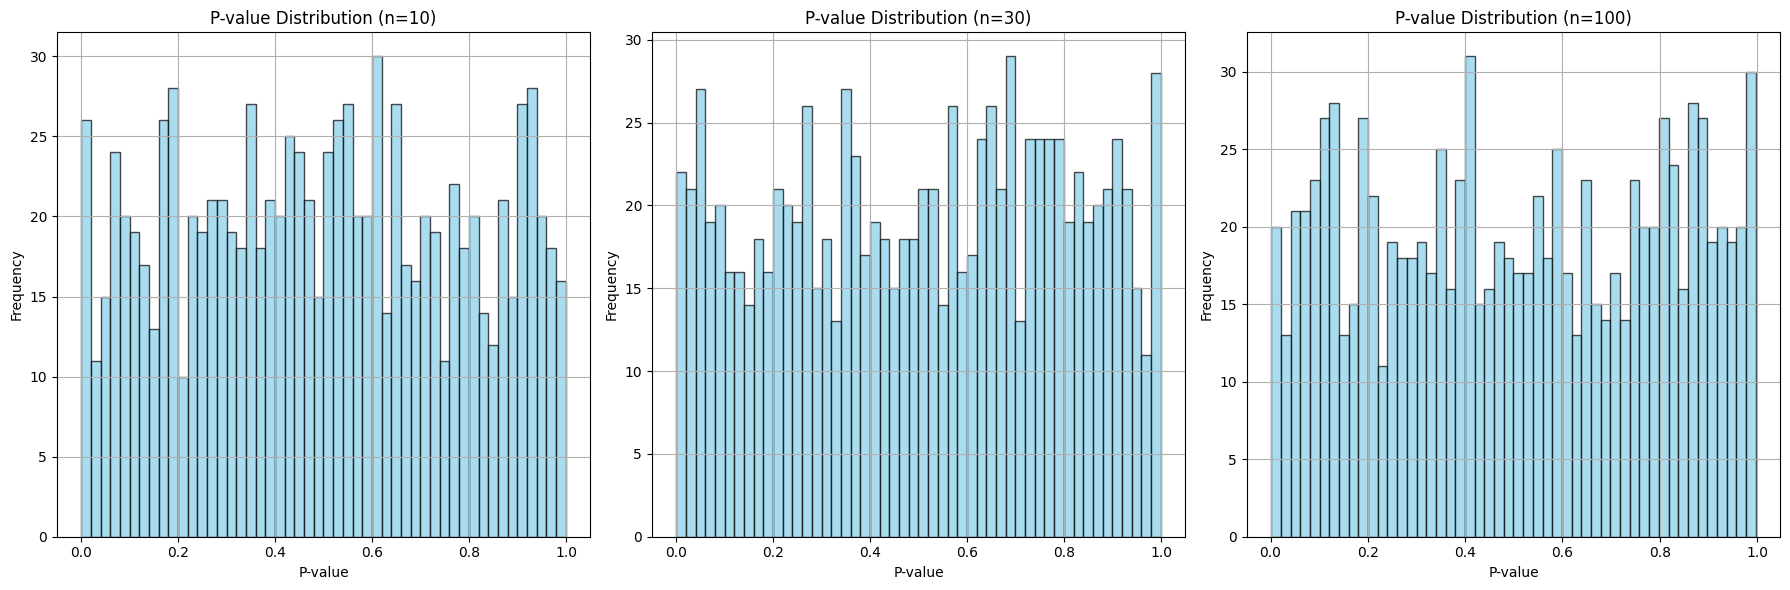

In [1]:
#假設兩組資料都來自標準常態母體 N(0,1) 且樣本數一樣同為 n。 對這兩組資料進行雙樣本 T 檢定，將得到一個 p-value。想透過實驗知道這個 p-value 的分佈，換句話說，如果將這個 p-value 當作一個隨機變數，它的分配會是什麼？先猜猜看，再來寫程式做實驗。實驗設定 n=10, 30, 100。
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 設定實驗參數
M = 1000  # 重複實驗次數
n_values = [10, 30, 100]  # 樣本數
mu1, mu2 = 0, 0  # 均值
sigma1, sigma2 = 1, 1  # 標準差

# 進行實驗並繪製 p-value 的分佈圖
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, n in enumerate(n_values):
    p_values = []
    
    for _ in range(M):
        # 生成兩組標準正態分佈的樣本
        x1 = np.random.normal(mu1, sigma1, n)
        x2 = np.random.normal(mu2, sigma2, n)
        
        # 進行雙樣本 T 檢定
        t_stat, p_value = ttest_ind(x1, x2, equal_var=True)
        p_values.append(p_value)
    
    # 繪製 p-value 的直方圖
    ax = axs[i]
    ax.hist(p_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'P-value Distribution (n={n})')
    ax.set_xlabel('P-value')
    ax.set_ylabel('Frequency')
    ax.grid(True)

plt.tight_layout()
plt.show()